<a href="https://colab.research.google.com/github/ollihansen90/Mathe-SH/blob/main/Dithering_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bildverarbeitung

## Grundlagen der Bildverarbeitung

Ein Bild besteht aus Pixeln. Die Größe eines Bildes ist durch durch die Anzahl der Pixel an den Seiten gegeben. \
Z.B.:
- 1280 × 720 (HD, 720p)
- 1920 × 1080 (Full HD, 1080p)
- 4096 × 2160 (4K)

Für Grauwertbilder hat jeder Pixel einen Wert. Häufig zwischen zwischen
- 0 und 1
- 0 und 255

Farbbilder haben für jeden Pixel mehrere Werte (zB. RGB, CMYK). \
Im Folgenden betrachten wir nur Grauwertbilder (ab jetzt einfach nur "Bild").

In der Programmierung können wir ein Bild als geschachtelte Listen von Werten darstellen.

In [ ]:
import matplotlib.pyplot as plt
erstes_bild = [
    [0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],

    [1,1,1,0,0,1,1,1,1,1,0,0,1,1,1,1],
    [1,1,0,0,0,1,1,1,1,1,0,0,0,1,1,1],
    [1,1,0,0,0,1,1,1,1,1,0,0,0,1,1,1],
    [1,1,1,0,0,1,1,1,1,1,0,0,1,1,1,1],

    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1],
    [1,1,1,1,1,0,0,0,0,0,0,1,1,1,1,1],
    [0,1,1,1,1,1,0,0,0,0,1,1,1,1,1,0],

    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0]
]

plt.imshow(erstes_bild) #, cmap = "binary"
plt.show()

Jetzt bist du dran!
Mittels for-schleifen und if-bedingungen kann man bilder mit interessanten Strukturen erschaffen!

In [ ]:
import numpy as np
hoehe = 16
breite = 16

bild = np.zeros((breite,hoehe))

for i in range(hoehe):
    for j in range(breite):
        #hier dein code
        # Beispiel 1: diagonale Linien
        if i == j:
            wert = 1
        elif i == (hoehe-1)-j:
            wert = 1
        # Beispiel 2: Rahmen
        elif i == 0 or j == 0 or i == hoehe-1 or j == breite-1:
            wert = 1
        else:
            wert = 0

        bild[i,j] = wert

plt.imshow(bild)
plt.show()

### Bilder in Python laden

In [ ]:
import imageio
import requests

url = "https://raw.githubusercontent.com/ollihansen90/Mathe-SH/refs/heads/main/data/Hase.jpeg" # oder Koala.jpeg oder Rose.jpg

bild = imageio.v2.imread(requests.get(url, stream=True).raw)

Das Bild ist augenscheinlich schwarz-weiß, allerdings hat das Format ".jpeg" immer 3 Farbkanäle. Ein Grauwertbild erreichen wir durch das Mitteln über alle Farben.

In [ ]:
import numpy as np
bild = np.mean(bild[:, :, :3], axis=2).astype(np.uint8)

### Bilder in Python anzeigen
Mit der Bibliothek *matplotlib* können wir unsere Bilder darstellen.

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(bild)
plt.show()

**Aber Achtung! Das Bild hat eigentlich gar keine Farben sondern nur Grauwerte!**

In [ ]:
plt.imshow(bild, cmap="gray")
plt.show()

Wie eingangs beschrieben können Grauwertbilder Werte aus dem Bereich [0,1] oder [0,255] haben. Das macht einen Unterschied bei der Darstellung des Bildes! Wir übergeben daher den Wertebereich der Pixelwerte:

In [ ]:
import numpy as np
print("Maximum ist", np.max(bild))
print("Minimum ist", np.min(bild))

In [ ]:
plt.imshow(bild, cmap = "gray", vmin = 0, vmax = 255)
plt.show()

Damit wir nicht immer die Bildanzeige neu schrieben müssen, kann diese Funktion genutzt werden:

In [ ]:
def bild_ausgabe(bild, min_value=0, max_value=1):
    plt.imshow(bild, cmap='gray', vmin=min_value, vmax=max_value)
    plt.show()

# Binarisierung

Ein Ansatz, um Speicherplatz zu sparen, ist es, das Bild in geringener Auflösung zu Speichern. Dabei gehen jedoch Details in der Struktur verloren. Gerade in der medizinischen Anwendung ist dies nicht gewollt.

Eine andere Möglichkeit ist es weniger Farben zu verwenden.
Der einfachste Ansatz ist es nur schwarze oder weiße Pixel zuzulassen.
Das ganze nennt man dann **"Binarisierung"**.

## Wie sieht eine solche Binarisierung, bei einem einzlenen Pixel aus?

In [ ]:
def binarisierung_pixel(pixel_wert, grenze):
    # 0 wenn der Wert kleiner als die Grenze ist, 1 sonst
    return pixel_wert >= grenze

## Und am ganzen Bild?

In [ ]:
def binarisierung_bild(bild, grenze):
    # bestimme Auflösung des Bildes
    x_laenge, y_laenge = bild.shape[:2]
    # erstelle ein leeres Bild in der gleichen Auflösung
    binarisiertes_bild = np.zeros((x_laenge, y_laenge))
    # prüfe jeden einzelnen Pixel gegen die gewählte Grenze
    for x in range(x_laenge):
        for y in range(y_laenge):
            binarisiertes_bild[x, y] = binarisierung_pixel(bild[x, y], grenze)
    return binarisiertes_bild

In [ ]:
binarisierung = binarisierung_bild(bild,128)
bild_ausgabe(binarisierung, 0, 1) # Achtung die Grenzen sind jetzt 0 und 1

Problem: Zu viele Details verloren. \
Zunächst könnte man versuchen, ob das verschieben der Grenze das Ergebnis verbessert:

In [ ]:
for grenze in [64, 128, 192]:
    bild_ausgabe(binarisierung_bild(bild,grenze),0,1)

Idee: Addiere die Bilder. Müssen nur so viele Farben speichern, wie Bilder addiert werden.

## Erstelle ein additives Bild

In [ ]:
grenzen = [64, 128, 192]
bild_mittel = np.zeros_like(bild,np.float64)
for i in range(len(grenzen)):
    bild_mittel += binarisierung_bild(bild,grenzen[i])
bild_ausgabe(bild_mittel,0,len(grenzen))
bild_ausgabe(bild,0,255)

## Rauschen
Häufig verbessert man die Ergebnisse in der Bildverarbeitung, wenn man einen kleinen Fehler in Form von Rauschen addiert.

Numpy liefert die Funktion
np.random.randint(*untere_grenze, obere_grenze, form_der_ausgabe*)

## Wie verrauschen (stören) wir einen Pixel?

In [ ]:
def rauschen_pixel(wert, rauschstaerke):

    return wert_ausgabe

## Und jetzt das ganze Bild

Welche Ansätze gibt es, ein "gestörtes" Bild zu erzeugen?

In [ ]:
def rauschen_bild(bild, rauschstaerke):
    x_laenge, y_laenge = bild.shape[:2]
    rauschen_bild = np.zeros((x_laenge, y_laenge))
    for x in range(x_laenge):
        for y in range(y_laenge):
            #Hier deine Lösung:
            #Tipp: Nutze die Funktion rauschen_pixel(wert, rauschstaerke)


    return rauschen_bild

In [ ]:
def rauschen_ganzes_bild(bild, rauschstaerke):
    x_laenge, y_laenge = bild.shape[:2]

    #Hier deine Lösung:


    return verrauschtes_bild

In [ ]:
bild_ausgabe(rauschen_bild(bild, 50), min_value=0, max_value=255)
bild_ausgabe(rauschen_ganzes_bild(bild, 50), min_value=0, max_value=255)

## Dithering
**Dithering** ist eine weitere Methode der Bildverarbeitung, um die Datengröße zu minimieren. Dabei werden wie bei der *Binarisierung* nur schwarz und weiße Pixel (z.B. 0 und 1) verwendet.

Um nun aber mehr Grauwerte darzustellen nutzt man aus, dass das menschliche Auge nicht jeden Pixel einzeln sieht, sondern mehrere miteinander verschwimmen können. Die Menge an schwarzen Pixeln bestimmt dabei wie dunkel die wahrgenommene Farbe ist.

#### Überlege dir, in welcher Reihenfolge die Pixel an- bzw. ausgeschaltet werden müssen.
Ersetze die 0en!

In [ ]:
#Dither-Matrix:
dither_matrix = np.array([[0,0],
                          [0,0]])

Jetzt müssen wir uns überlegen, ab welchem Wert ein Pixel in dem Dither-Pattern "angeschaltet", also weiß, wird!

In [ ]:
grenzen = [0,0,0,0]
dither_matrix = np.array([[grenzen[0],grenzen[0]],
                          [grenzen[0],grenzen[0]]])

Im folgenden Codeblock kannst du das Dithering an einem Pixel überprüfen:

In [ ]:
#lege Farbwert fest (aus 0 bis 255)
pixel_farbe = 128

fig, ax = plt.subplots()
ax.imshow(dither_matrix <= pixel_farbe)
plt.show()

### Jetzt wollen wir das ganze Bild dithern!

In [ ]:
def dither_bild(bild):
    n,m = bild.shape # Dimension des Ausgangbildes
    k = dither_matrix.shape[1] # Größe der Dithermatrix
    dithered_img = np.zeros([k*n,k*m]) # Bilddimesnion wenn jeder pixel ersetzt wurde
    for i in range(n):
        for j in range(m):
            # Deine Lösung hier


    return dithered_img

**Beachte:** Das Bild hat nun viermal soviele Pixel!

In [ ]:
bild_ausgabe(dither_bild(bild))

Vergleiche mit Ausgangsbild:

In [ ]:
bild_ausgabe(bild,0,255)

Selten enthalten Fotos tatsächlich Flächen die genau die gleiche Helligkeit haben. Rauschen hilft, diese Flächen beim Dithering zu vermeiden!

In [ ]:
bild_ausgabe(dither_bild(rauschen_ganzes_bild(bild, 40)), min_value=0, max_value=1)

Das Hasenbild enthält wenig Details. Dithering wird dann spannend wenn nicht nur Linien erhalten werden sollen, sondern Farbunterschiede und dadurch entstehende Strukturen. Wir Laden dazu ein neues Bild und führen die letzten Code-Blöcke erneut aus:

In [ ]:
url = "https://github.com/ollihansen90/Mathe-SH/blob/main/data/holstentor.jpg?raw=true" # oder Koala.jpeg oder Blume.jpg

bild = imageio.v2.imread(requests.get(url, stream=True).raw)
bild = np.mean(bild[:, :, :3], axis=2).astype(np.uint8)

Funktioniert das auch für 4x4-Pattern?

In [ ]:
dither_matrix = np.array([[  7, 135,  39, 167],
                          [199,  71, 231, 103],
                          [ 55, 183,  23, 151],
                          [247, 119, 215,  87]])

## Floyd-Steinberg:

Dithering muss nicht immer nur bedeuten, dass ein Pixel druch mehrere Schwarz-Weiße Pixel ersetzt wird. Angenommen, wir können Grauwerte drucken/darstellen gleichen sich auf der "Kosten"-Seite die Vor- und Nachteile hier nämlich aus. Brauchen wir weniger separate Farben, wird das Bild größer. Auf der anderen Seite können wir also die Bild-Dimensionen gleich lassen, brauchen dafür aber mehr Farben. Ein solcher Ansatz wurde von Floyd und Steinberg entwickelt:

Die Idee:


1.   Erstelle eine Farbpalette
2.   Vergleiche den aktuellen Pixel gegen die Farbpalette, wähle das beste Match.
3. Bestimme den Fehler der durch diese Approximation entsteht (Quantisierungsfehler)
4. "Vererbe" diesen Fehler an die noch nicht veränderten Pixel in der Umgebung

Dieser Algorithmus wird von oben links nach unten rechts druch das Bild abgearbeitet.



Der Anteilige Quantisierungsfehler ist in dieser Abbildung dargestellt: 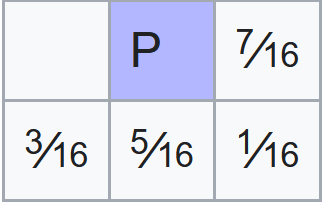

In [ ]:
# Funktion um das beste Farb-Match zu finden
def finde_farbe(alt_farbe = 0, n = 4):
    schrittweite = 255//n
    farbpalette = [i * schrittweite for i in range(n+1)]
    neu_farbe = min(farbpalette, key=lambda x: abs(x - alt_farbe))
    return neu_farbe

In [ ]:
def floyd_steinberg(eingabe):
    [n,m] = eingabe.shape[:2]
    eingabe = eingabe.astype(np.float32)
    for x in range(1,n-1):
        for y in range(m-1):
            #TODO: Finde das beste Farb-Match und bestimme den Quantisierungsfehler:


            quantisierungsfehler = 0 # zu verändern

            # Hier wird der Quantisierungsfehler nach der obigen Abbildung angewandt
            eingabe[x + 1, y    ] += quantisierungs_fehler * 7 / 16
            eingabe[x - 1, y + 1] += quantisierungs_fehler * 3 / 16
            eingabe[x    , y + 1] += quantisierungs_fehler * 5 / 16
            eingabe[x + 1, y + 1] += quantisierungs_fehler * 1 / 16
    return np.clip(eingabe, 0, 255).astype(np.uint8)

In [ ]:
bild_ausgabe(floyd_steinberg(bild), min_value = 0, max_value = 255)